CUBO ORIGINAL


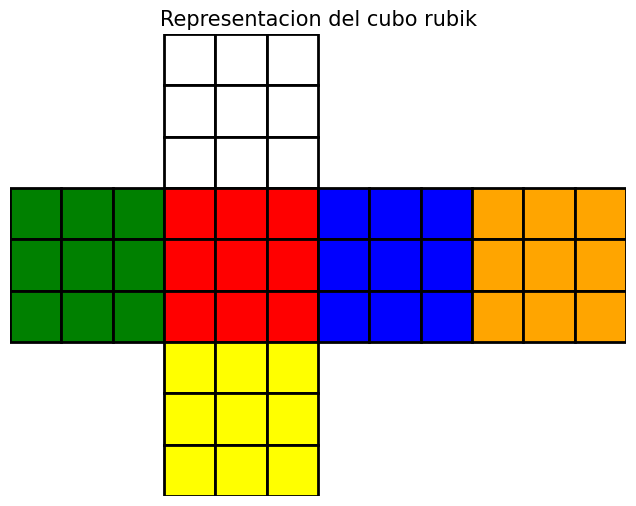

CUBO MEZCLADO


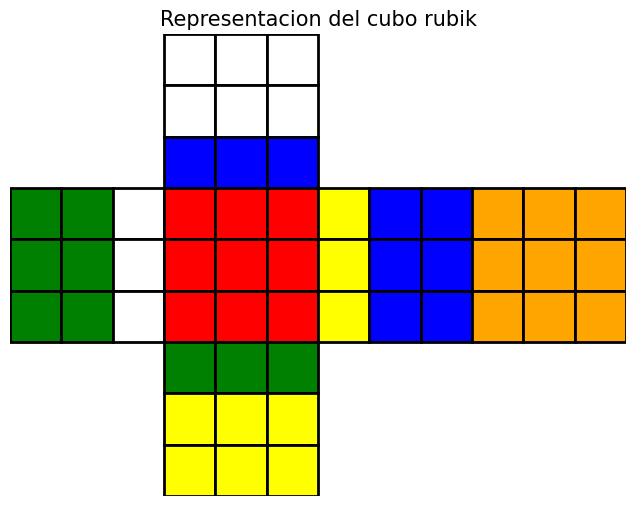

SOLUCION:
['Z1R']
CUBO RESUELTO


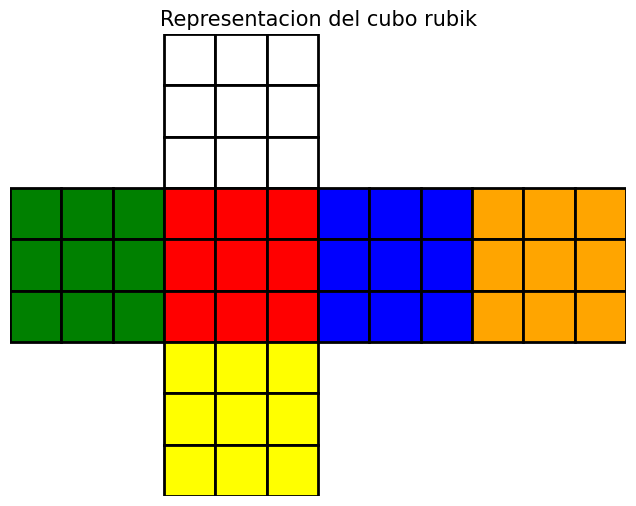

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import deque

#CUBO inicial

CUBE = []

CUBE.append([" ", " ", " ", "W", "W", "W", " ", " ", " ", " ", " ", " "])
CUBE.append([" ", " ", " ", "W", "W", "W", " ", " ", " ", " ", " ", " "])
CUBE.append([" ", " ", " ", "W", "W", "W", " ", " ", " ", " ", " ", " "])
CUBE.append(["G", "G", "G", "R", "R", "R", "B", "B", "B", "O", "O", "O"])
CUBE.append(["G", "G", "G", "R", "R", "R", "B", "B", "B", "O", "O", "O"])
CUBE.append(["G", "G", "G", "R", "R", "R", "B", "B", "B", "O", "O", "O"])
CUBE.append([" ", " ", " ", "Y", "Y", "Y", " ", " ", " ", " ", " ", " "])
CUBE.append([" ", " ", " ", "Y", "Y", "Y", " ", " ", " ", " ", " ", " "])
CUBE.append([" ", " ", " ", "Y", "Y", "Y", " ", " ", " ", " ", " ", " "])


color_map = {
    "W": "white",
    "Y": "yellow",
    "G": "green",
    "R": "red",
    "B": "blue",
    "O": "orange",
    " ": None
}

#CUBO

def dibujar_cubo(datos_cubo):

    fig, ax = plt.subplots(figsize=(12,6))

    filas = len(datos_cubo)
    columnas = len(datos_cubo[0])

    for r in range(filas):
        for c in range(columnas):

            char_color = datos_cubo[r][c]
            color_web = color_map.get(char_color)

            if color_web:

                rect = patches.Rectangle(
                    (c, filas - 1 - r),
                    1,
                    1,
                    linewidth=2,
                    edgecolor="black",
                    facecolor=color_web
                )

                ax.add_patch(rect)

    ax.set_xlim(0, columnas)
    ax.set_ylim(0, filas)

    ax.set_aspect("equal")
    ax.axis("off")

    plt.title("Representacion del cubo rubik", fontsize=15)
    plt.show()

#MOVIMIENTOS

def move(m, cubo):

    nuevo = [fila[:] for fila in cubo]

    #Z1L

    if m == "Z1L":

        cara = [fila[3:6] for fila in cubo[3:6]]
        cara_rot = [list(f) for f in zip(*cara)][::-1]

        for i in range(3):
            nuevo[3+i][3:6] = cara_rot[i]

        top = cubo[2][3:6]
        left = [cubo[3+i][2] for i in range(3)]
        down = cubo[6][3:6]
        right = [cubo[3+i][6] for i in range(3)]

        for i in range(3):

            nuevo[3+i][2] = top[2-i]
            nuevo[6][i+3] = left[i]
            nuevo[3+i][6] = down[2-i]
            nuevo[2][5-i] = right[i]

    #Z1R

    elif m == "Z1R":

        cara = [fila[3:6] for fila in cubo[3:6]]
        cara_rot = [list(f) for f in zip(*cara[::-1])]

        for i in range(3):
            nuevo[3+i][3:6] = cara_rot[i]

        top = cubo[2][3:6]
        left = [cubo[3+i][2] for i in range(3)]
        down = cubo[6][3:6]
        right = [cubo[3+i][6] for i in range(3)]

        for i in range(3):

            nuevo[3+i][6] = top[i]
            nuevo[6][5-i] = right[i]
            nuevo[3+i][2] = down[i]
            nuevo[2][3+i] = left[2-i]

    #Z2L

    elif m == "Z2L":

        top = cubo[1][3:6]
        left = [cubo[3+i][1] for i in range(3)]
        down = cubo[7][3:6]
        right = [cubo[3+i][7] for i in range(3)]

        for i in range(3):

            nuevo[3+i][1] = top[2-i]
            nuevo[7][i+3] = left[i]
            nuevo[3+i][7] = down[2-i]
            nuevo[1][5-i] = right[i]

    #Z2R

    elif m == "Z2R":

        top = cubo[1][3:6]
        left = [cubo[3+i][1] for i in range(3)]
        down = cubo[7][3:6]
        right = [cubo[3+i][7] for i in range(3)]

        for i in range(3):

            nuevo[3+i][7] = top[i]
            nuevo[7][5-i] = right[i]
            nuevo[3+i][1] = down[i]
            nuevo[1][3+i] = left[2-i]

    #Z3L

    elif m == "Z3L":

        cara = [fila[9:12] for fila in cubo[3:6]]
        cara_rot = [list(f) for f in zip(*cara)][::-1]

        for i in range(3):
            nuevo[3+i][9:12] = cara_rot[i]

        top = cubo[0][3:6]
        left = [cubo[3+i][0] for i in range(3)]
        down = cubo[8][3:6]
        right = [cubo[3+i][8] for i in range(3)]

        for i in range(3):

            nuevo[3+i][0] = top[i]
            nuevo[8][i+3] = left[2-i]
            nuevo[3+i][8] = down[i]
            nuevo[0][5-i] = right[i]

    #Z3R

    elif m == "Z3R":

        cara = [fila[9:12] for fila in cubo[3:6]]
        cara_rot = [list(f) for f in zip(*cara[::-1])]

        for i in range(3):
            nuevo[3+i][9:12] = cara_rot[i]

        top = cubo[0][3:6]
        left = [cubo[3+i][0] for i in range(3)]
        down = cubo[8][3:6]
        right = [cubo[3+i][8] for i in range(3)]

        for i in range(3):

            nuevo[3+i][8] = top[2-i]
            nuevo[8][5-i] = right[i]
            nuevo[3+i][0] = down[2-i]
            nuevo[0][3+i] = left[i]

    #Y1D

    elif m == "Y1D":

        front = [cubo[3+i][3] for i in range(3)]
        top = [cubo[i][3] for i in range(3)]
        back = [cubo[5-i][11] for i in range(3)]
        down = [cubo[6+i][3] for i in range(3)]

        for i in range(3):

            nuevo[6+i][3] = front[i]
            nuevo[5-i][11] = down[i]
            nuevo[i][3] = back[i]
            nuevo[3+i][3] = top[i]

    #Y1U

    elif m == "Y1U":

        front = [cubo[3+i][3] for i in range(3)]
        top = [cubo[i][3] for i in range(3)]
        back = [cubo[5-i][11] for i in range(3)]
        down = [cubo[6+i][3] for i in range(3)]

        for i in range(3):

            nuevo[3+i][3] = down[i]
            nuevo[i][3] = front[i]
            nuevo[5-i][11] = top[i]
            nuevo[6+i][3] = back[i]

    #Y2D

    elif m == "Y2D":

        front = [cubo[3+i][4] for i in range(3)]
        top = [cubo[i][4] for i in range(3)]
        back = [cubo[5-i][10] for i in range(3)]
        down = [cubo[6+i][4] for i in range(3)]

        for i in range(3):

            nuevo[6+i][4] = front[i]
            nuevo[5-i][10] = down[i]
            nuevo[i][4] = back[i]
            nuevo[3+i][4] = top[i]

    #Y2U

    elif m == "Y2U":

        front = [cubo[3+i][4] for i in range(3)]
        top = [cubo[i][4] for i in range(3)]
        back = [cubo[5-i][10] for i in range(3)]
        down = [cubo[6+i][4] for i in range(3)]

        for i in range(3):

            nuevo[3+i][4] = down[i]
            nuevo[i][4] = front[i]
            nuevo[5-i][10] = top[i]
            nuevo[6+i][4] = back[i]

    #Y3D

    elif m == "Y3D":

        front = [cubo[3+i][5] for i in range(3)]
        top = [cubo[i][5] for i in range(3)]
        back = [cubo[5-i][9] for i in range(3)]
        down = [cubo[6+i][5] for i in range(3)]

        for i in range(3):

            nuevo[6+i][5] = front[i]
            nuevo[5-i][9] = down[i]
            nuevo[i][5] = back[i]
            nuevo[3+i][5] = top[i]

    #Y3U

    elif m == "Y3U":

        front = [cubo[3+i][5] for i in range(3)]
        top = [cubo[i][5] for i in range(3)]
        back = [cubo[5-i][9] for i in range(3)]
        down = [cubo[6+i][5] for i in range(3)]

        for i in range(3):

            nuevo[3+i][5] = down[i]
            nuevo[i][5] = front[i]
            nuevo[5-i][9] = top[i]
            nuevo[6+i][5] = back[i]

    #X1L

    elif m == "X1L":

        fila = cubo[5][:]
        nuevo[5] = fila[3:] + fila[:3]

    #X1R

    elif m == "X1R":

        fila = cubo[5][:]
        nuevo[5] = fila[-3:] + fila[:-3]

    #X2L

    elif m == "X2L":

        fila = cubo[4][:]
        nuevo[4] = fila[3:] + fila[:3]

    #X2R

    elif m == "X2R":

        fila = cubo[4][:]
        nuevo[4] = fila[-3:] + fila[:-3]

    #X3L

    elif m == "X3L":

        fila = cubo[3][:]
        nuevo[3] = fila[3:] + fila[:3]

    #X3R

    elif m == "X3R":

        fila = cubo[3][:]
        nuevo[3] = fila[-3:] + fila[:-3]

    return nuevo


def cube_to_tuple(cubo):

    return tuple(tuple(fila) for fila in cubo)


#Movimientos

MOVES = [

    "Z1L","Z1R",
    "Z2L","Z2R",
    "Z3L","Z3R",

    "Y1D","Y1U",
    "Y2D","Y2U",
    "Y3D","Y3U",

    "X1L","X1R",
    "X2L","X2R",
    "X3L","X3R"
]



def bfs(inicial, objetivo):

    Q = deque()

    visitados = set()

    nodo_inicial = {

        "cube": inicial,
        "path": []
    }

    Q.append(nodo_inicial)

    visitados.add(cube_to_tuple(inicial))

    while Q:

        actual = Q.popleft()

        estado_actual = actual["cube"]

        if cube_to_tuple(estado_actual) == cube_to_tuple(objetivo):

            return actual["path"]

        for movimiento in MOVES:

            hijo = move(movimiento, estado_actual)

            hijo_hash = cube_to_tuple(hijo)

            if hijo_hash not in visitados:

                visitados.add(hijo_hash)

                nuevo_nodo = {

                    "cube": hijo,
                    "path": actual["path"] + [movimiento]
                }

                Q.append(nuevo_nodo)

    return None

#ingresar el cubo aqui

print("CUBO ORIGINAL")
dibujar_cubo(CUBE)

mezclado = move("Z1L", CUBE)
mezclado = move("X1R", mezclado)

print("CUBO MEZCLADO")
dibujar_cubo(mezclado)

solucion = bfs(mezclado, CUBE)

print("SOLUCION:")
print(solucion)

estado = mezclado

for mov in solucion:

    estado = move(mov, estado)

print("CUBO RESUELTO")
dibujar_cubo(estado)